# Определение тональности и токсичности комментариев

Подготовил: Рахмаев

Цель работы: построить и оценить модель нейронной сети для определения тональности и токсичности русскоязычных комментариев на основе датасета с разметкой типов сообщений.

## План работы

1. Загрузка и первичный анализ датасета.
2. Предобработка русскоязычного текста.
3. Подготовка данных для обучения нейросети.
4. Обучение рекуррентной нейронной сети для бинарной классификации токсично/нет.
5. Оценка качества модели на тестовой выборке.
6. Сохранение модели и токенизатора для использования в веб‑приложении.

In [18]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import pickle

In [19]:
nltk.download("stopwords")
stop_words = set(stopwords.words("russian"))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rakhm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Загрузка и анализ исходного датасета

Используется текстовый датасет комментариев с разметкой типов сообщений: нормальный комментарий, оскорбление, угроза, обсценная лексика. Датасет расположен в папке с примерами работ.

In [20]:
path_file_txt = "dataset.txt"

In [21]:
def create_df(path):
    data_list = []
    with open(path, encoding="utf-8") as file:
        for line in file:
            labels = line.split()[0]
            text = line[len(labels) + 1 :].strip()
            labels = labels.split(",")
            mask = [
                1 if "__label__NORMAL" in labels else 0,
                1 if "__label__INSULT" in labels else 0,
                1 if "__label__THREAT" in labels else 0,
                1 if "__label__OBSCENITY" in labels else 0,
            ]
            data_list.append((text, *mask))
    return pd.DataFrame(
        data_list,
        columns=["comment", "normal", "insult", "threat", "obscenity"],
    )

df = create_df(path_file_txt)
df["comment"] = df["comment"].astype(str)
df.head()

,comment,normal,insult,threat,obscenity
0,скотина! что сказать,0,1,0,0
1,я сегодня проезжала по рабочей и между домами ...,1,0,0,0
2,очередной лохотрон. зачем придумывать очередно...,1,0,0,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",1,0,0,0
4,а когда мы статус агрогородка получили?,1,0,0,0


In [22]:
df[["normal", "insult", "threat", "obscenity"]].sum()

normal       203685
insult        36826
threat        12027
obscenity      4261
dtype: int64

Создадим бинарный признак токсичности, который равен 1, если комментарий содержит хотя бы один из типов токсичного поведения, и 0, если комментарий нормальный.

In [23]:
df["toxic"] = ((df["insult"] + df["threat"] + df["obscenity"]) > 0).astype(int)
df["toxic"].value_counts(normalize=True)

toxic
0    0.820351
1    0.179649
Name: proportion, dtype: float64

### Визуализация распределения классов

Построим графики, показывающие распределение исходных типов комментариев и итогового признака токсичности.

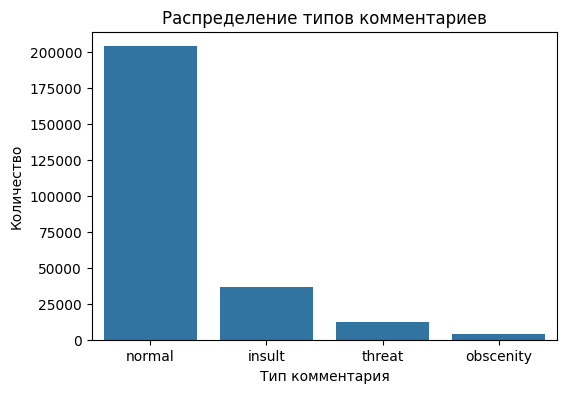

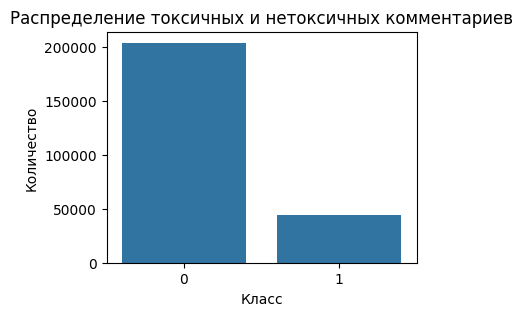

In [24]:
label_counts = df[["normal", "insult", "threat", "obscenity"]].sum()
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xlabel("Тип комментария")
plt.ylabel("Количество")
plt.title("Распределение типов комментариев")
plt.show()

plt.figure(figsize=(4, 3))
sns.countplot(x=df["toxic"])
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.title("Распределение токсичных и нетоксичных комментариев")
plt.show()

## Предобработка русскоязычного текста

Выполняется приведение к нижнему регистру, удаление лишних символов, токенизация по пробелам и удаление стоп‑слов. После этого формируется очищенная текстовая колонка.

In [25]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^а-яa-z0-9ё ]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["comment"].apply(preprocess_text)
mask = df["clean_text"].str.len() > 0
df = df[mask].reset_index(drop=True)
df[["comment", "clean_text", "toxic"]].head()

,comment,clean_text,toxic
0,скотина! что сказать,скотина сказать,1
1,я сегодня проезжала по рабочей и между домами ...,сегодня проезжала рабочей домами снитенко гомо...,0
2,очередной лохотрон. зачем придумывать очередно...,очередной лохотрон придумывать очередной налог...,0
3,"ретро дежавю ... сложно понять чужое сердце , ...",ретро дежавю сложно понять чужое сердце лиш ощ...,0
4,а когда мы статус агрогородка получили?,статус агрогородка получили,0


### Длина очищенных комментариев

Рассмотрим распределение количества слов в очищенных комментариях.

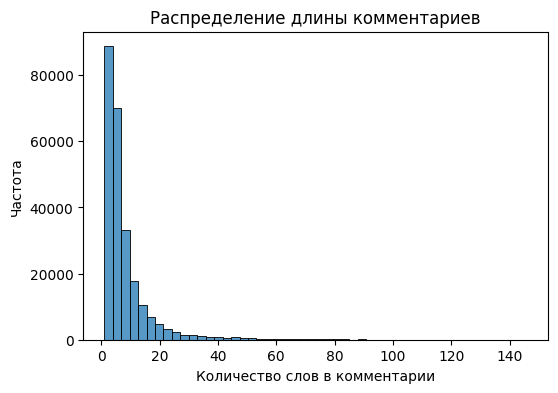

In [26]:
df["text_len"] = df["clean_text"].str.split().str.len()
plt.figure(figsize=(6, 4))
sns.histplot(df["text_len"], bins=50)
plt.xlabel("Количество слов в комментарии")
plt.ylabel("Частота")
plt.title("Распределение длины комментариев")
plt.show()

## Подготовка данных для обучения

Разделим выборку на обучающую, валидационную и тестовую, затем выполним токенизацию и приведение текстов к фиксированной длине последовательности слов.

In [27]:
X = df["clean_text"].values
y = df["toxic"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42,
)

max_words = 50000
max_len = 40

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_valid_pad = pad_sequences(X_valid_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

X_train_pad.shape, X_valid_pad.shape, X_test_pad.shape

((197830, 40), (24729, 40), (24729, 40))

## Модель рекуррентной нейронной сети

Для классификации используется двунаправленная рекуррентная нейросеть на основе слоя LSTM поверх эмбеддингов слов.

In [28]:
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.3))
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

c:\Users\rakhm\anaconda3\envs\ml-iris\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True,
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_valid_pad, y_valid),
    epochs=5,
    batch_size=512,
    callbacks=[early_stopping],
)
history.history.keys()

Epoch 1/5
387/387 ━━━━━━━━━━━━━━━━━━━━ 59s 146ms/step - accuracy: 0.9230 - loss: 0.2128 - val_accuracy: 0.9643 - val_loss: 0.1129
Epoch 2/5
387/387 ━━━━━━━━━━━━━━━━━━━━ 59s 154ms/step - accuracy: 0.9739 - loss: 0.0827 - val_accuracy: 0.9650 - val_loss: 0.1103
Epoch 3/5
387/387 ━━━━━━━━━━━━━━━━━━━━ 58s 151ms/step - accuracy: 0.9813 - loss: 0.0596 - val_accuracy: 0.9641 - val_loss: 0.1280


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

### Графики обучения модели

Проследим, как менялись функция потерь и точность на обучающей и валидационной выборках.

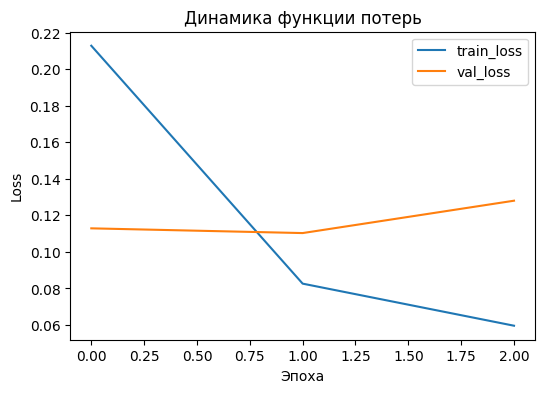

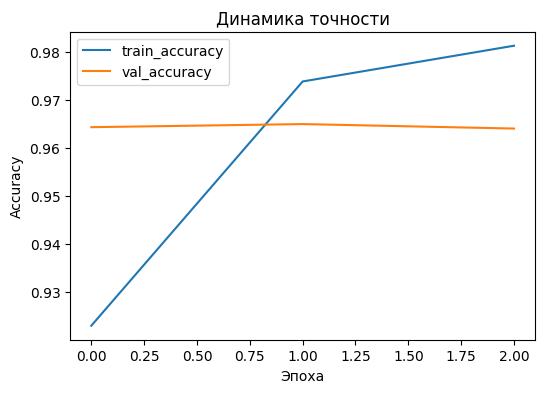

In [30]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(6, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Динамика функции потерь")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Динамика точности")
plt.legend()
plt.show()

### Оценка качества модели на тестовой выборке

In [31]:
y_pred_proba = model.predict(X_test_pad).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

773/773 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     20269
           1       0.91      0.89      0.90      4460

    accuracy                           0.96     24729
   macro avg       0.94      0.94      0.94     24729
weighted avg       0.96      0.96      0.96     24729



array([[19874,   395],
       [  471,  3989]])

## Сохранение модели и токенизатора

Сохраним нейросеть и токенизатор, которые далее будут использоваться в веб‑приложении на FastAPI для классификации новых комментариев, полученных из базы данных.

In [32]:
model.save("comment_tone_rakhmaev_model.h5")
with open("comment_tone_rakhmaev_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

### Функция для применения модели к новым комментариям

Определим вспомогательную функцию, которая будет использоваться в веб‑приложении для классификации одного комментария.

In [33]:
def predict_comment(text):
    clean = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([clean])
    pad = pad_sequences(seq, maxlen=max_len)
    proba = float(model.predict(pad)[0][0])
    label = "toxic" if proba >= 0.5 else "normal"
    return label, proba

examples = [
    "Ты молодец, отличная работа",
    "Ты полный идиот, ничего не умеешь",
]

for text in examples:
    print(text)
    print(predict_comment(text))

Ты молодец, отличная работа
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
('normal', 0.001523499726317823)
Ты полный идиот, ничего не умеешь
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
('toxic', 0.9778721928596497)


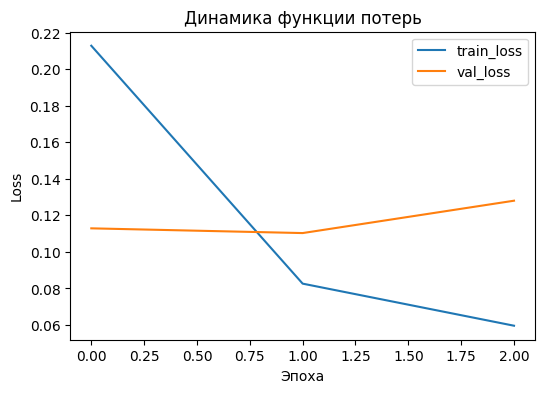

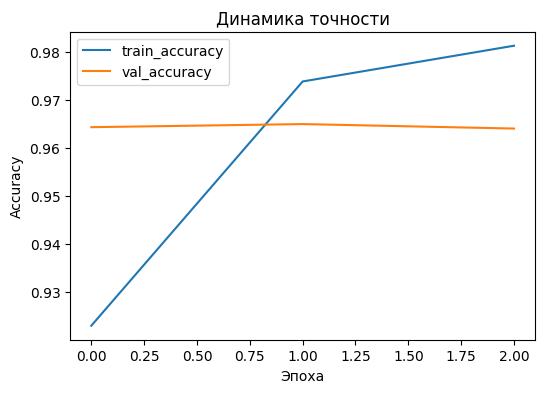

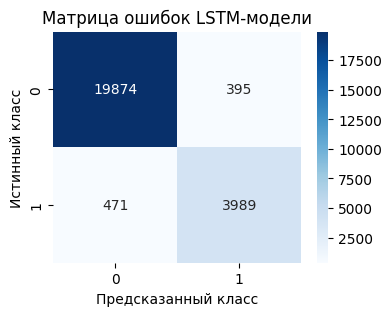

In [34]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(6, 4))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Динамика функции потерь")
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Динамика точности")
plt.legend()
plt.show()

cm_lstm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок LSTM-модели")
plt.show()

## Выводы

1. Подготовлен датасет русскоязычных комментариев с разметкой по типам токсичности.

2. На основе разметки создан бинарный признак: токсичный/нетоксичный комментарий.

3. Выполнена предобработка текста: очистка, приведение к нижнему регистру, удаление стоп‑слов, токенизация.

4. Данные разделены на обучающую, валидационную и тестовую выборки с сохранением распределения классов.

5. Обучена LSTM‑модель. Использован EarlyStopping, чтобы избежать переобучения.

6. На тестовой выборке модель показала высокое качество: accuracy около 0.96, F1‑мера для токсичного класса около 0.89.